# Exploratory Data Analysis (EDA) - IPVS Dataset

In [23]:
# Importando bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando dados
file_path = "../data/clean/ipvs_esp-merge.csv"
df = pd.read_csv(file_path, sep=';')

In [24]:
# Overview básico
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nHead:\n", df.head())

# Tipos de dados
print("\nData Types:\n", df.dtypes)

# Valores ausentes
print("\nMissing Values:\n", df.isnull().sum())

Shape: (2572, 5)

Columns:
 Index(['cod_ibge', 'grupo_ipvs', 'n_pessoas', 'n_domicilios', 'n_setores'], dtype='str')

Head:
      cod_ibge                   grupo_ipvs  n_pessoas  n_domicilios  n_setores
0  ADAMANTINA   Baixíssima Vulnerabilidade         99            36          1
1  ADAMANTINA  Muito Baixa Vulnerabilidade      20816          8316         49
2  ADAMANTINA        Baixa Vulnerabilidade       4015          1667         10
3  ADAMANTINA        Média Vulnerabilidade       5683          2140         12
4  ADAMANTINA         Alta Vulnerabilidade       3181          1162          7

Data Types:
 cod_ibge          str
grupo_ipvs        str
n_pessoas       int64
n_domicilios    int64
n_setores       int64
dtype: object

Missing Values:
 cod_ibge        0
grupo_ipvs      0
n_pessoas       0
n_domicilios    0
n_setores       0
dtype: int64


> Podemos ver que nosso dataset é composto de 2572 linhas e 5 colunas. Não há valores ausentes.
Uma explicação mais detalhada sobre os dados pode ser vista no [Dicionário de Dados](../docs/data/DICIONARIO_DE_DADOS.md).

In [30]:
# =========================
#  Insights iniciais
# =========================

print("\nResumo estatístico:\n", df.describe())


Resumo estatístico:
           n_pessoas  n_domicilios    n_setores  pessoas_por_domicilio
count  2.572000e+03  2.572000e+03  2572.000000            2572.000000
mean   1.700201e+04  6.253967e+03    36.088647               2.761622
std    1.150063e+05  4.357784e+04   258.120457               0.181031
min    8.100000e+01  2.400000e+01     1.000000               2.131579
25%    1.215500e+03  4.495000e+02     3.000000               2.635234
50%    3.243000e+03  1.205000e+03     7.000000               2.758710
75%    9.646000e+03  3.486000e+03    21.000000               2.881295
max    4.651411e+06  1.752049e+06  9949.000000               3.500000


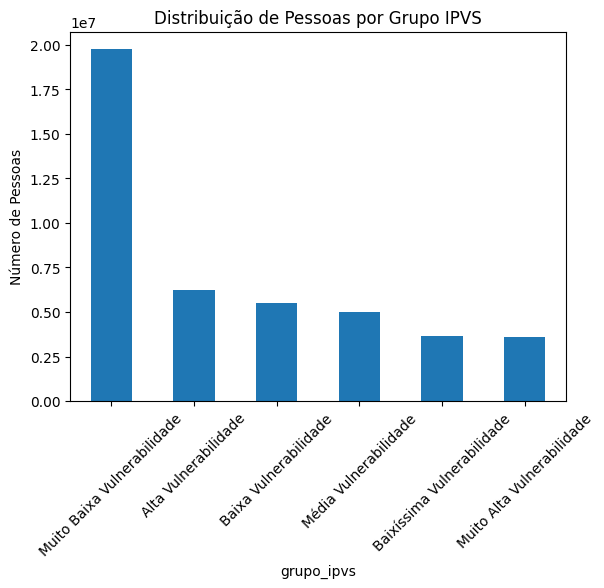

In [31]:
# =========================
# 1. Distribuição geral
# =========================

dist = df.groupby("grupo_ipvs")["n_pessoas"].sum().sort_values(ascending=False)

plt.figure()
dist.plot(kind="bar")
plt.title("Distribuição de Pessoas por Grupo IPVS")
plt.ylabel("Número de Pessoas")
plt.xticks(rotation=45)
plt.show()

> O gráfico acima demonstra a distribuição de pessoas por grupo de vulnerabilidade na notação 1 x 10^7. Há aproximadamente 20 milhões de pessoas em *Muito Baixa Vulnerabilidade*, enquanto há aproximadamente 3,5 milhões de pessoas em *Muito Alta Vulnerabilidade*.

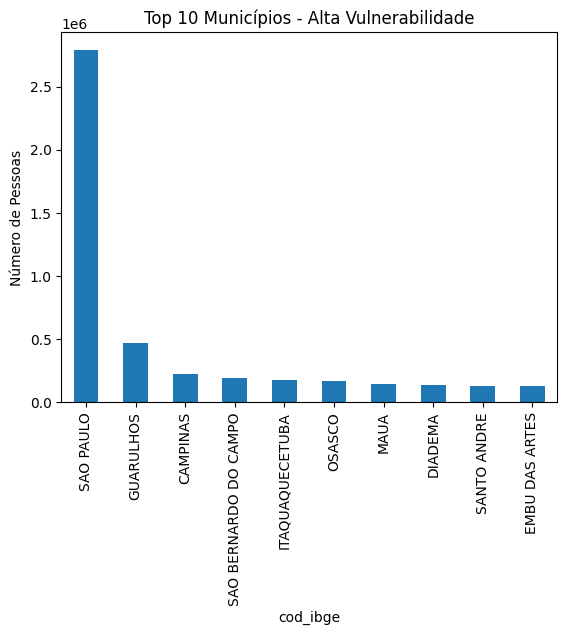

In [32]:
# =========================
# 2. Ranking de municípios (Alta vulnerabilidade)
# =========================

alta = df[df["grupo_ipvs"].str.contains("Alta", case=False, na=False)]
ranking = alta.groupby("cod_ibge")["n_pessoas"].sum().sort_values(ascending=False).head(10)

plt.figure()
ranking.plot(kind="bar")
plt.title("Top 10 Municípios - Alta Vulnerabilidade")
plt.ylabel("Número de Pessoas")
plt.show()

In [33]:
# =========================
# 3. Proporção por município
# =========================

total_por_cidade = df.groupby("cod_ibge")["n_pessoas"].sum()

prop = df.copy()
prop["proporcao"] = prop.apply(lambda x: x["n_pessoas"] / total_por_cidade[x["cod_ibge"]], axis=1)

print("\nProporções exemplo:\n", prop.head())


Proporções exemplo:
      cod_ibge                   grupo_ipvs  n_pessoas  n_domicilios  \
0  ADAMANTINA   Baixíssima Vulnerabilidade         99            36   
1  ADAMANTINA  Muito Baixa Vulnerabilidade      20816          8316   
2  ADAMANTINA        Baixa Vulnerabilidade       4015          1667   
3  ADAMANTINA        Média Vulnerabilidade       5683          2140   
4  ADAMANTINA         Alta Vulnerabilidade       3181          1162   

   n_setores  pessoas_por_domicilio  proporcao  
0          1               2.750000   0.002930  
1         49               2.503127   0.615967  
2         10               2.408518   0.118808  
3         12               2.655607   0.168166  
4          7               2.737522   0.094129  


> Aqui, a ideia é sabermos qual fração da população de cada município de São Paulo (estado) está em determinado grupo de vulnerabilidade. Na prática podemos interpretar da seguinte maneira:

| cod_ibge   | grupo_ipvs                 | n_pessoas | proporcao |
| ---------- | -------------------------- | --------- | --------- |
| ADAMANTINA | Baixíssima Vulnerabilidade | 99        | 0.002930  |
| ADAMANTINA | Alta vulnerabilidade       | 3181      | 0.094129  |

Isto quer dizer que em ADAMANTINA aproximadamente 0,3% da população está em baixíssimo estado de vulnerabilidade, enquanto 9% está em alta vulnerabilidade.


<Figure size 640x480 with 0 Axes>

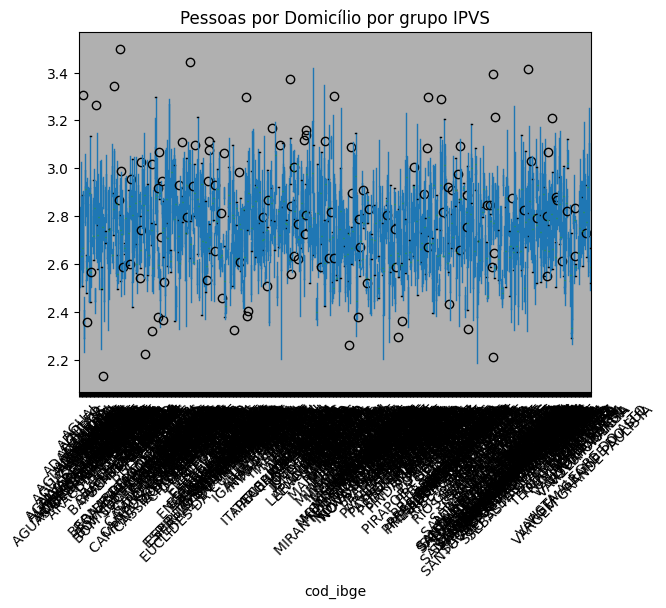

In [34]:
# =========================
# 4. Pessoas por domicílio
# =========================

df["pessoas_por_domicilio"] = df["n_pessoas"] / df["n_domicilios"]
plt.figure()
df.boxplot(column="pessoas_por_domicilio", by="cod_ibge")
plt.title("Pessoas por Domicílio por grupo IPVS")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

In [36]:
# =========================
# 5. Próximos passos sugeridos
# =========================

print(r"""
Sugestões:
- Melhorar a visualização de pessoas por Domicílio por grupo IPVS
- Visualizar a densidade por setor
- Calcular % de alta vulnerabilidade por município
- Criar clusters de municípios
- Cruzar com dados externos (renda, saúde, etc.)
- Gerar mapas geográficos
- Detectar perfis de municípios onde há maior ou menor vulnerabilidade etc...
""")


Sugestões:
- Melhorar a visualização de pessoas por Domicílio por grupo IPVS
- Visualizar a densidade por setor
- Calcular % de alta vulnerabilidade por município
- Criar clusters de municípios
- Cruzar com dados externos (renda, saúde, etc.)
- Gerar mapas geográficos
- Detectar perfis de municípios onde há maior ou menor vulnerabilidade etc...

